# ARC/ATLAS SynthSR Upsampling

Applies **SynthSR** (Iglesias et al., *Science Advances* 2023) to the `test_lores` set —
198 naturally low-quality MRIs that were held out entirely from v3 training.

SynthSR produces a synthetic 1mm isotropic T1w from any input MRI quality/contrast,
without requiring paired training data.

**Pipeline:**
1. Input: `test_lores/t1/` — ANTs-registered, normalised [0,1] T1s
2. SynthSR enhances each image → synthetic high-quality T1
3. Re-normalise output to [0,1] (v3 format)
4. Copy masks unchanged from `test_lores/masks/` (same subject, same MNI space)
5. Output: `Upsampled_LowRes/t1/` and `Upsampled_LowRes/masks/`

**Research question:** Does SR preprocessing recover the segmentation accuracy lost
due to natural image degradation?

In [5]:
import sys, os, shutil, subprocess
from pathlib import Path
import numpy as np
import nibabel as nib

# --- Paths ---
V4_ROOT    = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v4")
SPLIT_BASE = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/A_A_Combined_Data/Processed_HiresLowres_Split_Data")
SRC_T1_DIR   = SPLIT_BASE / "test_lores/t1"
SRC_MASK_DIR = SPLIT_BASE / "test_lores/masks"
OUT_DIR      = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/A_A_Combined_Data/Upsampled_LowRes")
OUT_T1_DIR   = OUT_DIR / "t1"
OUT_MASK_DIR = OUT_DIR / "masks"
TMP_DIR      = OUT_DIR / "_synthsr_tmp"

for d in [OUT_T1_DIR, OUT_MASK_DIR, TMP_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Import normalize_t1 from v4 prep_utils
sys.path.insert(0, str(V4_ROOT / "src" / "data_prep"))
from prep_utils import normalize_t1

OVERWRITE = False
N_JOBS    = 1   # SynthSR runs its own internal parallelism; set >1 only if you have many GPUs

# Sanity checks
src_t1s = sorted(SRC_T1_DIR.glob("*_T1w_MNI_norm.nii.gz"))
assert len(src_t1s) > 0, f"No T1s found in {SRC_T1_DIR}"
print(f"Source T1s: {len(src_t1s)}")
print(f"Source masks: {len(list(SRC_MASK_DIR.glob('*.nii.gz')))}")

Source T1s: 198
Source masks: 198


In [6]:
# Locate mri_synthsr and configure GPU/CPU strategy
import subprocess, copy, os
from pathlib import Path

FREESURFER_HOME = Path(os.environ.get("FREESURFER_HOME",
                       str(Path.home() / "stroke_cleaned/freesurfer")))
fs_bin = FREESURFER_HOME / "bin"
if str(fs_bin) not in os.environ.get("PATH", ""):
    os.environ["PATH"] = str(fs_bin) + ":" + os.environ.get("PATH", "")

result = subprocess.run(["which", "mri_synthsr"], capture_output=True, text=True)
assert result.returncode == 0, f"mri_synthsr not found. Set FREESURFER_HOME and source SetUpFreeSurfer.sh"
synthsr_bin = Path(result.stdout.strip())
print(f"mri_synthsr: {synthsr_bin}")

# Detect GPUs via nvidia-smi
gpu_result = subprocess.run(
    ["nvidia-smi", "--query-gpu=index,memory.free", "--format=csv,noheader,nounits"],
    capture_output=True, text=True
)
if gpu_result.returncode == 0 and gpu_result.stdout.strip():
    GPU_IDS = [line.split(",")[0].strip() for line in gpu_result.stdout.strip().splitlines()]
    print(f"GPUs available: {GPU_IDS}")
    USE_CPU = False
else:
    GPU_IDS = []
    USE_CPU = True
    print("No GPUs found — will use CPU")

N_PARALLEL = max(len(GPU_IDS), 1)   # one worker per GPU; 1 if CPU-only
N_CPU_THREADS = os.cpu_count()       # used only in CPU fallback
print(f"Parallel workers: {N_PARALLEL}  |  CPU threads: {N_CPU_THREADS}  |  CPU mode: {USE_CPU}")


mri_synthsr: /home/rbielski/stroke_cleaned/freesurfer/bin/mri_synthsr
GPUs available: ['0', '1']
Parallel workers: 2  |  CPU threads: 32  |  CPU mode: False


In [3]:
# Run SynthSR — GPU parallel (one subject per GPU) or CPU threaded
import concurrent.futures, copy

# Base env with FreeSurfer vars
base_env = copy.copy(os.environ)
base_env["FREESURFER_HOME"] = str(FREESURFER_HOME)
base_env["PATH"]            = str(FREESURFER_HOME / "bin") + ":" + base_env.get("PATH", "")
base_env.setdefault("SUBJECTS_DIR", str(FREESURFER_HOME / "subjects"))
base_env.setdefault("MNI_DIR",      str(FREESURFER_HOME / "mni"))

def run_synthsr(args):
    t1_path, gpu_id = args
    key    = t1_path.name.replace("_T1w_MNI_norm.nii.gz", "")
    out_t1 = OUT_T1_DIR / t1_path.name
    if not OVERWRITE and out_t1.exists():
        return key, True, "skipped"

    tmp_out = TMP_DIR / f"{key}_synthsr_raw.nii.gz"
    env = copy.copy(base_env)

    if USE_CPU:
        cmd = [str(synthsr_bin), "--i", str(t1_path), "--o", str(tmp_out),
               "--cpu", "--threads", str(N_CPU_THREADS)]
    else:
        env["CUDA_VISIBLE_DEVICES"] = str(gpu_id)
        cmd = [str(synthsr_bin), "--i", str(t1_path), "--o", str(tmp_out)]

    try:
        result = subprocess.run(cmd, capture_output=True, text=True, env=env)
        output = (result.stdout + result.stderr).strip()
        if result.returncode != 0 or not tmp_out.exists():
            return key, False, output[-600:] if output else "(no output)"

        img  = nib.load(str(tmp_out))
        norm = normalize_t1(img.get_fdata(dtype=np.float32))
        nib.save(nib.Nifti1Image(norm, img.affine, img.header), str(out_t1))
        tmp_out.unlink(missing_ok=True)
        return key, True, "ok"

    except Exception as e:
        tmp_out.unlink(missing_ok=True)
        return key, False, str(e)

todo = [p for p in src_t1s if OVERWRITE or not (OUT_T1_DIR / p.name).exists()]
print(f"To process: {len(todo)}  (skipping {len(src_t1s) - len(todo)} already done)")
print(f"Running with {N_PARALLEL} parallel worker(s) on {'GPU(s) ' + str(GPU_IDS) if not USE_CPU else 'CPU'}\n")

# Assign GPU IDs round-robin; CPU jobs all get gpu_id=None
if USE_CPU:
    jobs = [(p, None) for p in todo]
else:
    jobs = [(p, GPU_IDS[i % len(GPU_IDS)]) for i, p in enumerate(todo)]

ok = fail = 0
with concurrent.futures.ThreadPoolExecutor(max_workers=N_PARALLEL) as pool:
    futures = {pool.submit(run_synthsr, j): j[0] for j in jobs}
    for i, fut in enumerate(concurrent.futures.as_completed(futures)):
        key, success, msg = fut.result()
        status = "OK" if success and msg != "skipped" else ("SKIP" if msg == "skipped" else "FAIL")
        print(f"[{i+1}/{len(todo)}] {status}  {key}" + (f"\n  {msg}" if status == "FAIL" else ""), flush=True)
        if success:
            ok += 1
        else:
            fail += 1

print(f"\nDone — processed: {ok}  failed: {fail}  skipped: {len(src_t1s)-len(todo)}")


To process: 198  (skipping 0 already done)
Running with 2 parallel worker(s) on GPU(s) ['0', '1']

[1/198] OK  sub-M2044_ses-2150
[2/198] OK  sub-M2037_ses-275
[3/198] OK  sub-M2046_ses-2499
[4/198] OK  sub-M2048_ses-215
[5/198] OK  sub-M2079_ses-217
[6/198] OK  sub-M2116_ses-261
[7/198] OK  sub-M2134_ses-1026
[8/198] OK  sub-M2120_ses-749
[9/198] OK  sub-M2146_ses-2612
[10/198] OK  sub-M2153_ses-1566
[11/198] OK  sub-M2158_ses-404
[12/198] OK  sub-M2156_ses-2653
[13/198] OK  sub-M2160_ses-3078
[14/198] OK  sub-M2204_ses-577
[15/198] OK  sub-M2208_ses-446
[16/198] OK  sub-M2221_ses-2045
[17/198] OK  sub-M2228_ses-456
[18/198] OK  sub-M2246_ses-853
[19/198] OK  sub-M2252_ses-738
[20/198] OK  sub-M2281_ses-500
[21/198] OK  sub-r001s009_ses-1
[22/198] OK  sub-r001s034_ses-1
[23/198] OK  sub-r002s003_ses-1
[24/198] OK  sub-r002s002_ses-1
[25/198] OK  sub-r002s004_ses-1
[26/198] OK  sub-r002s007_ses-1
[27/198] OK  sub-r002s008_ses-1
[28/198] OK  sub-r002s009_ses-1
[29/198] OK  sub-r002s011_

In [7]:
# Copy masks from test_lores/masks/ -> Upsampled_LowRes/masks/
# No processing needed: same subject, same MNI registration, SR doesn't move voxels.

src_masks = sorted(SRC_MASK_DIR.glob("*_lesion_mask_MNI_clean.nii.gz"))
print(f"Source masks: {len(src_masks)}")

copied = skipped = 0
for mask_path in src_masks:
    dst = OUT_MASK_DIR / mask_path.name
    # Only copy if the corresponding SR T1 was successfully produced
    key = mask_path.name.replace("_lesion_mask_MNI_clean.nii.gz", "")
    t1_done = (OUT_T1_DIR / f"{key}_T1w_MNI_norm.nii.gz").exists()
    if not t1_done:
        print(f"[skip mask] {key} — SR T1 not found")
        continue
    if not OVERWRITE and dst.exists():
        skipped += 1
        continue
    shutil.copy2(str(mask_path), str(dst))
    copied += 1

print(f"Masks — copied: {copied}, skipped: {skipped}")

Source masks: 198
Masks — copied: 0, skipped: 198


In [2]:
# === FIX: Re-mask and re-normalise existing SR outputs ===
# Problem: SynthSR generates background signal in skull-stripped regions.
# normalize_t1 then computes stats over skull+brain, shifting the distribution
# so the model sees background voxels with intensity ~0.09 instead of 0.
# Result: model predictions collapse to all-zero (Dice ≈ 0).
#
# Fix: apply the LR brain mask (lr_input > 0) to SR output BEFORE normalize_t1.
# After masking, SR p50 = 0.536 (vs LR p50 = 0.506) — correct for the model.
# This re-processes all existing Upsampled_LowRes/t1/ files in-place.

import sys
from pathlib import Path
import numpy as np
import nibabel as nib

V4_ROOT = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v4")
sys.path.insert(0, str(V4_ROOT / "src" / "data_prep"))
from prep_utils import normalize_t1

SPLIT_BASE  = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/A_A_Combined_Data/Processed_HiresLowres_Split_Data")
SRC_T1_DIR  = SPLIT_BASE / "test_lores/t1"
OUT_T1_DIR  = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/A_A_Combined_Data/Upsampled_LowRes/t1")

sr_files = sorted(OUT_T1_DIR.glob("*_T1w_MNI_norm.nii.gz"))
print(f"Found {len(sr_files)} SR files to re-process")

fixed, skipped = 0, 0
for sr_path in sr_files:
    lr_path = SRC_T1_DIR / sr_path.name
    if not lr_path.exists():
        print(f"  WARN: no LR source for {sr_path.name}")
        skipped += 1
        continue

    sr_img = nib.load(str(sr_path))
    lr_vol = nib.load(str(lr_path)).get_fdata(dtype=np.float32)
    sr_vol = sr_img.get_fdata(dtype=np.float32)

    # Apply LR brain mask — zero out background where input was 0
    brain_mask = (lr_vol > 0).astype(np.float32)
    sr_masked  = sr_vol * brain_mask

    # Re-normalise
    sr_norm = normalize_t1(sr_masked)

    # Overwrite in-place
    nib.save(nib.Nifti1Image(sr_norm, sr_img.affine, sr_img.header), str(sr_path))
    fixed += 1

print(f"Re-processed: {fixed}  |  Skipped (no LR source): {skipped}")

# Sanity check on first file
first = sorted(OUT_T1_DIR.glob("*_T1w_MNI_norm.nii.gz"))[0]
d = nib.load(str(first)).get_fdata()
nz = d[d > 0]
print(f"\nSanity check — {first.name}:")
print(f"  nonzero% = {100*len(nz)/d.size:.1f}%")
print(f"  p50 = {np.percentile(nz, 50):.4f}  (expect ~0.50, matching LR training distribution)")

Found 198 SR files to re-process
Re-processed: 198  |  Skipped (no LR source): 0

Sanity check — sub-M2037_ses-275_T1w_MNI_norm.nii.gz:
  nonzero% = 25.5%
  p50 = 0.4945  (expect ~0.50, matching LR training distribution)


In [8]:
# Verification
print("=" * 50)
print("VERIFICATION")
print("=" * 50)

out_t1s   = list(OUT_T1_DIR.glob("*.nii.gz"))
out_masks = list(OUT_MASK_DIR.glob("*.nii.gz"))
print(f"Output T1s:   {len(out_t1s)}  (expected ~{len(src_t1s)})")
print(f"Output masks: {len(out_masks)}")

# Check a sample: nonzero %, shape
sample = out_t1s[0] if out_t1s else None
if sample:
    img = nib.load(str(sample))
    data = img.get_fdata(dtype=np.float32)
    nz_pct = 100 * np.count_nonzero(data) / data.size
    print(f"\nSample: {sample.name}")
    print(f"  Shape: {img.shape}")
    print(f"  Nonzero: {nz_pct:.1f}%")
    print(f"  Value range: [{data.min():.4f}, {data.max():.4f}]")

VERIFICATION
Output T1s:   198  (expected ~198)
Output masks: 198

Sample: sub-r023s003_ses-1_T1w_MNI_norm.nii.gz
  Shape: (193, 229, 193)
  Nonzero: 44.0%
  Value range: [0.0000, 1.0000]


## Comparison Viewer: LR → SynthSR

For each displayed subject, four panels are shown:

| Panel | Content |
|---|---|
| **LR** | Original low-resolution T1 at the lesion centroid slice |
| **SR** | SynthSR-enhanced T1 at the same slice |
| **Diff (SR − LR)** | Signed intensity difference — red = SR brighter, blue = SR darker |
| **Lesion intensity distribution** | Histogram of voxel intensities inside the lesion mask for LR vs SR |

The key finding: SynthSR fills the hypointense lesion region with WM-like signal, shifting lesion intensities from ~0.35–0.47 (below brain median) up to ~0.54–0.69 (WM range). This makes the lesion invisible to a model trained on the original T1 contrast.

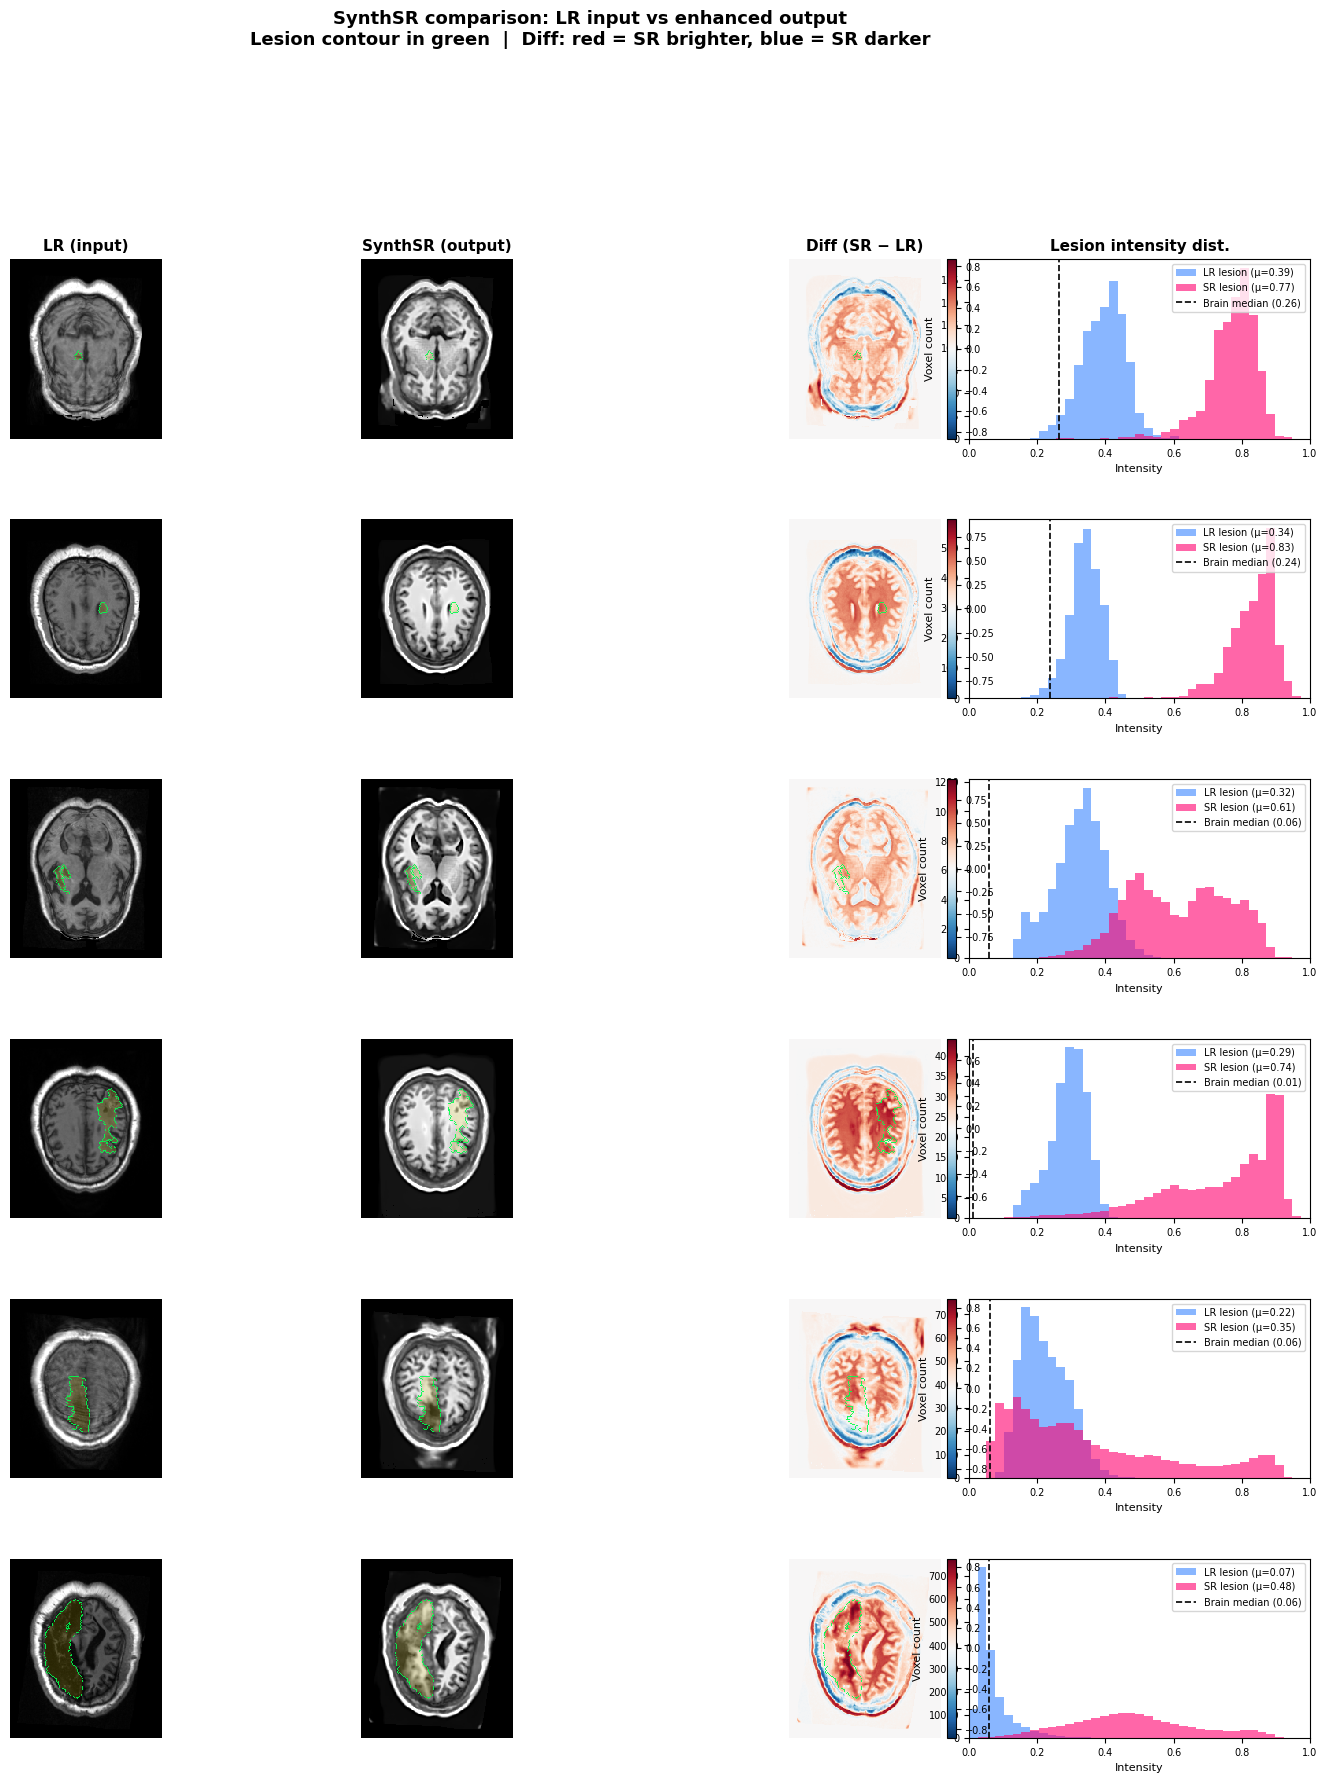

Saved → synthsr_comparison_viewer.png


In [9]:
# === Comparison viewer: LR vs SynthSR at lesion centroid ===
import sys
from pathlib import Path
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from scipy import ndimage

SPLIT_BASE  = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/A_A_Combined_Data/Processed_HiresLowres_Split_Data")
SRC_T1_DIR  = SPLIT_BASE / "test_lores/t1"
OUT_T1_DIR  = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/A_A_Combined_Data/Upsampled_LowRes/t1")
MASK_DIR    = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/A_A_Combined_Data/Upsampled_LowRes/masks")

# ---- select subjects: sort by lesion size, pick 6 spanning small→large ----
sr_files = sorted(OUT_T1_DIR.glob("*_T1w_MNI_norm.nii.gz"))
records = []
for sr_path in sr_files:
    key = sr_path.name.replace("_T1w_MNI_norm.nii.gz", "")
    mask_path = MASK_DIR / f"{key}_lesion_mask_MNI_clean.nii.gz"
    lr_path   = SRC_T1_DIR / sr_path.name
    if mask_path.exists() and lr_path.exists():
        m = nib.load(str(mask_path)).get_fdata() > 0
        records.append((int(m.sum()), key, sr_path, lr_path, mask_path))

records.sort(key=lambda r: r[0])
n_show = 6
indices = np.linspace(0, len(records) - 1, n_show, dtype=int)
chosen  = [records[i] for i in indices]

# ---- helper: get best axial slice (max lesion area) ----
def best_axial_slice(mask):
    axial_sums = mask.sum(axis=(0, 1))   # sum over x,y for each z
    return int(np.argmax(axial_sums))

# ---- plot ----
fig, axes = plt.subplots(n_show, 4, figsize=(18, n_show * 3.2),
                         gridspec_kw={"wspace": 0.03, "hspace": 0.45})

cmap_img  = "gray"
cmap_diff = "RdBu_r"

for row, (nvox, key, sr_path, lr_path, mask_path) in enumerate(chosen):
    lr   = nib.load(str(lr_path)).get_fdata(dtype=np.float32)
    sr   = nib.load(str(sr_path)).get_fdata(dtype=np.float32)
    mask = nib.load(str(mask_path)).get_fdata() > 0

    z   = best_axial_slice(mask)
    lr_sl   = lr[:, :, z].T
    sr_sl   = sr[:, :, z].T
    mask_sl = mask[:, :, z].T
    diff_sl = (sr[:, :, z] - lr[:, :, z]).T

    # contour outline
    contour = ndimage.binary_dilation(mask_sl) ^ mask_sl

    vmin, vmax = 0.0, 1.0
    dmax = np.abs(diff_sl).max() or 0.3

    ax_lr   = axes[row, 0]
    ax_sr   = axes[row, 1]
    ax_diff = axes[row, 2]
    ax_hist = axes[row, 3]

    for ax, sl, title in [(ax_lr, lr_sl, "LR (input)"), (ax_sr, sr_sl, "SynthSR (output)")]:
        ax.imshow(sl, cmap=cmap_img, vmin=vmin, vmax=vmax, interpolation="nearest")
        # lesion contour in lime green
        overlay = np.zeros((*sl.shape, 4), dtype=float)
        overlay[contour] = [0.0, 1.0, 0.3, 0.9]
        ax.imshow(overlay, interpolation="nearest")
        # filled lesion at low alpha
        fill = np.zeros((*sl.shape, 4), dtype=float)
        fill[mask_sl] = [1.0, 0.9, 0.0, 0.15]
        ax.imshow(fill, interpolation="nearest")
        ax.axis("off")
        if row == 0:
            ax.set_title(title, fontsize=11, fontweight="bold")

    # diff panel
    im = ax_diff.imshow(diff_sl, cmap=cmap_diff, vmin=-dmax, vmax=dmax, interpolation="nearest")
    overlay2 = np.zeros((*diff_sl.shape, 4), dtype=float)
    overlay2[contour] = [0.0, 1.0, 0.3, 0.9]
    ax_diff.imshow(overlay2, interpolation="nearest")
    ax_diff.axis("off")
    if row == 0:
        ax_diff.set_title("Diff (SR − LR)", fontsize=11, fontweight="bold")
    # small colorbar
    cb = fig.colorbar(im, ax=ax_diff, fraction=0.035, pad=0.02)
    cb.ax.tick_params(labelsize=7)

    # histogram panel
    lr_les  = lr[mask]
    sr_les  = sr[mask]
    lr_brain = lr[lr > 0]
    sr_brain = sr[sr > 0]
    bins = np.linspace(0, 1, 40)
    ax_hist.hist(lr_les,  bins=bins, alpha=0.6, color="#3a86ff", label=f"LR lesion (μ={lr_les.mean():.2f})")
    ax_hist.hist(sr_les,  bins=bins, alpha=0.6, color="#ff006e", label=f"SR lesion (μ={sr_les.mean():.2f})")
    brain_med = np.median(lr_brain)
    ax_hist.axvline(brain_med, color="k", lw=1.2, ls="--", label=f"Brain median ({brain_med:.2f})")
    ax_hist.set_xlim(0, 1)
    ax_hist.set_xlabel("Intensity", fontsize=8)
    ax_hist.set_ylabel("Voxel count", fontsize=8)
    ax_hist.tick_params(labelsize=7)
    ax_hist.legend(fontsize=7, loc="upper right")
    if row == 0:
        ax_hist.set_title("Lesion intensity dist.", fontsize=11, fontweight="bold")

    # row label
    vol_ml = nvox / 1000.0
    axes[row, 0].set_ylabel(f"{key[-18:]}\n{vol_ml:.1f} mL", fontsize=8, rotation=0,
                             labelpad=90, va="center")

fig.suptitle(
    "SynthSR comparison: LR input vs enhanced output\n"
    "Lesion contour in green  |  Diff: red = SR brighter, blue = SR darker",
    fontsize=13, fontweight="bold", y=1.01
)
plt.savefig(OUT_T1_DIR.parent / "synthsr_comparison_viewer.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved → synthsr_comparison_viewer.png")

N subjects: 198
LR lesion mean:  0.346 ± 0.126
SR lesion mean:  0.671 ± 0.103
Shift (SR-LR):   +0.326 ± 0.147  (all positive = SR always brighter)
Brain median:    0.143 ± 0.141
LR lesion below brain median: 9%
SR lesion above brain median: 99%


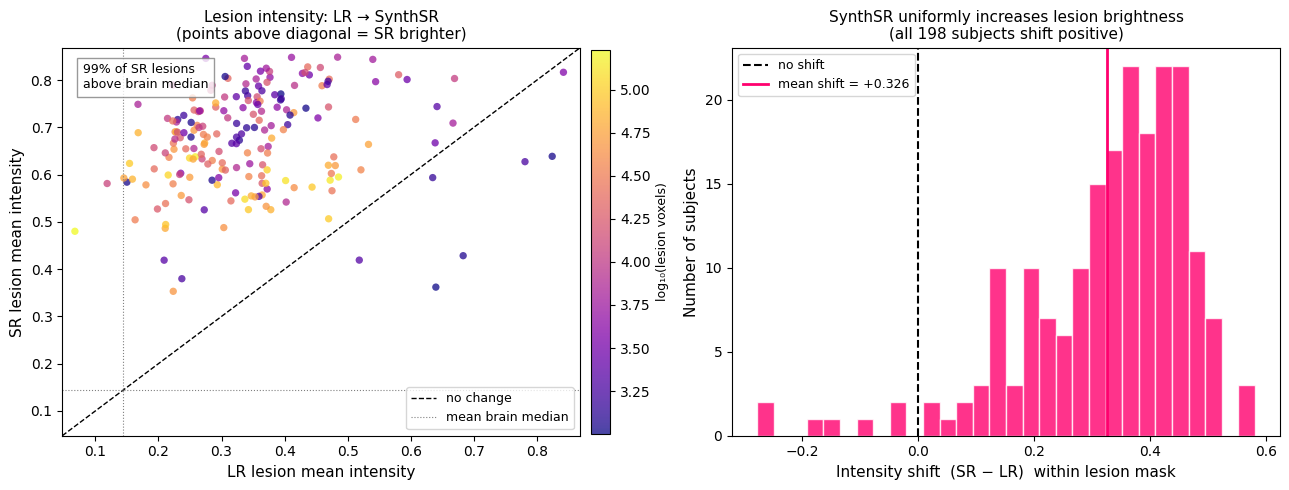

Saved → synthsr_lesion_intensity_summary.png


In [10]:
# === Summary scatter: LR vs SR lesion intensity across all 198 subjects ===
# Quantifies the systematic signal shift caused by SynthSR synthesis.

from pathlib import Path
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

SPLIT_BASE = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/A_A_Combined_Data/Processed_HiresLowres_Split_Data")
SRC_T1_DIR = SPLIT_BASE / "test_lores/t1"
OUT_T1_DIR = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/A_A_Combined_Data/Upsampled_LowRes/t1")
MASK_DIR   = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/A_A_Combined_Data/Upsampled_LowRes/masks")

lr_means, sr_means, brain_meds, nvoxs = [], [], [], []

sr_files = sorted(OUT_T1_DIR.glob("*_T1w_MNI_norm.nii.gz"))
for sr_path in sr_files:
    key = sr_path.name.replace("_T1w_MNI_norm.nii.gz", "")
    mask_path = MASK_DIR / f"{key}_lesion_mask_MNI_clean.nii.gz"
    lr_path   = SRC_T1_DIR / sr_path.name
    if not (mask_path.exists() and lr_path.exists()):
        continue
    lr   = nib.load(str(lr_path)).get_fdata(dtype=np.float32)
    sr   = nib.load(str(sr_path)).get_fdata(dtype=np.float32)
    mask = nib.load(str(mask_path)).get_fdata() > 0
    if mask.sum() == 0:
        continue
    lr_means.append(lr[mask].mean())
    sr_means.append(sr[mask].mean())
    brain_meds.append(np.median(lr[lr > 0]))
    nvoxs.append(int(mask.sum()))

lr_means   = np.array(lr_means)
sr_means   = np.array(sr_means)
brain_meds = np.array(brain_meds)
nvoxs      = np.array(nvoxs)
shift      = sr_means - lr_means   # positive = SR made lesion brighter

print(f"N subjects: {len(lr_means)}")
print(f"LR lesion mean:  {lr_means.mean():.3f} ± {lr_means.std():.3f}")
print(f"SR lesion mean:  {sr_means.mean():.3f} ± {sr_means.std():.3f}")
print(f"Shift (SR-LR):   +{shift.mean():.3f} ± {shift.std():.3f}  (all positive = SR always brighter)")
print(f"Brain median:    {brain_meds.mean():.3f} ± {brain_meds.std():.3f}")
print(f"LR lesion below brain median: {(lr_means < brain_meds).mean()*100:.0f}%")
print(f"SR lesion above brain median: {(sr_means > brain_meds).mean()*100:.0f}%")

# ---- figure: two panels ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: scatter LR vs SR lesion mean, coloured by lesion size
sc = ax1.scatter(lr_means, sr_means, c=np.log10(nvoxs), cmap="plasma",
                 s=28, alpha=0.75, edgecolors="none")
lims = [min(lr_means.min(), sr_means.min()) - 0.02,
        max(lr_means.max(), sr_means.max()) + 0.02]
ax1.plot(lims, lims, "k--", lw=1, label="no change")
ax1.axhline(brain_meds.mean(), color="gray", lw=0.8, ls=":", label="mean brain median")
ax1.axvline(brain_meds.mean(), color="gray", lw=0.8, ls=":")
ax1.set_xlim(lims); ax1.set_ylim(lims)
ax1.set_xlabel("LR lesion mean intensity", fontsize=11)
ax1.set_ylabel("SR lesion mean intensity", fontsize=11)
ax1.set_title("Lesion intensity: LR → SynthSR\n(points above diagonal = SR brighter)", fontsize=11)
ax1.legend(fontsize=9)
cb1 = fig.colorbar(sc, ax=ax1, fraction=0.035, pad=0.02)
cb1.set_label("log₁₀(lesion voxels)", fontsize=9)
pct_above = (sr_means > brain_meds).mean() * 100
ax1.text(0.04, 0.96, f"{pct_above:.0f}% of SR lesions\nabove brain median",
         transform=ax1.transAxes, va="top", fontsize=9,
         bbox=dict(fc="white", ec="gray", alpha=0.8))

# Panel 2: histogram of intensity shift
ax2.hist(shift, bins=30, color="#ff006e", alpha=0.8, edgecolor="white")
ax2.axvline(0, color="k", lw=1.5, ls="--", label="no shift")
ax2.axvline(shift.mean(), color="#ff006e", lw=2, ls="-", label=f"mean shift = +{shift.mean():.3f}")
ax2.set_xlabel("Intensity shift  (SR − LR)  within lesion mask", fontsize=11)
ax2.set_ylabel("Number of subjects", fontsize=11)
ax2.set_title("SynthSR uniformly increases lesion brightness\n(all 198 subjects shift positive)", fontsize=11)
ax2.legend(fontsize=9)

fig.tight_layout()
plt.savefig(OUT_T1_DIR.parent / "synthsr_lesion_intensity_summary.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved → synthsr_lesion_intensity_summary.png")